# Fairlearn for HR Resume Screening

**Scenario:** TechTalent Solutions discovered bias in their resume screening AI. Let's mitigate it with Microsoft Fairlearn.

## Business Problem
- Only 15% minority candidates recommended
- Client diversity lawsuits increasing

In [ ]:
# Keep Binder session alive during workshop
import time
import threading
from IPython.display import clear_output

def workshop_keepalive():
    """Keep session alive during workshop presentations"""
    count = 0
    while count < 200:  # Run for ~16 hours max
        time.sleep(300)  # 5 minutes
        count += 1
        clear_output(wait=True)
        print(f" Workshop session active - {time.strftime('%H:%M:%S')}")
        print(f" Runtime: {count * 5} minutes")
        print("Continue with the workshop content below...")

# Start in background
threading.Thread(target=workshop_keepalive, daemon=True).start()

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#read in dataset
df = pd.read_csv('data/resume_dataset.csv')
print(f"Overall hiring rate: {df['hired'].mean():.1%}")
print("Hiring by ethnicity:")
print(df.groupby('ethnicity')['hired'].mean().round(3))

Overall hiring rate: 40.0%
Hiring by ethnicity:
ethnicity
Asian       0.145
Black       0.148
Hispanic    0.147
White       0.574
Name: hired, dtype: float64


In [3]:
df.head()

,years_experience,education_score,skills_match,previous_company_tier,ethnicity,gender,hired
0,6.490142,5.649643,0.527301,2,White,Male,1
1,4.585207,6.710963,0.693759,2,Black,Male,0
2,6.943066,5.415160,0.703603,2,Black,Female,0
3,9.569090,6.384077,0.794526,1,White,Male,1
4,4.297540,3.212771,0.426628,3,Hispanic,Male,0


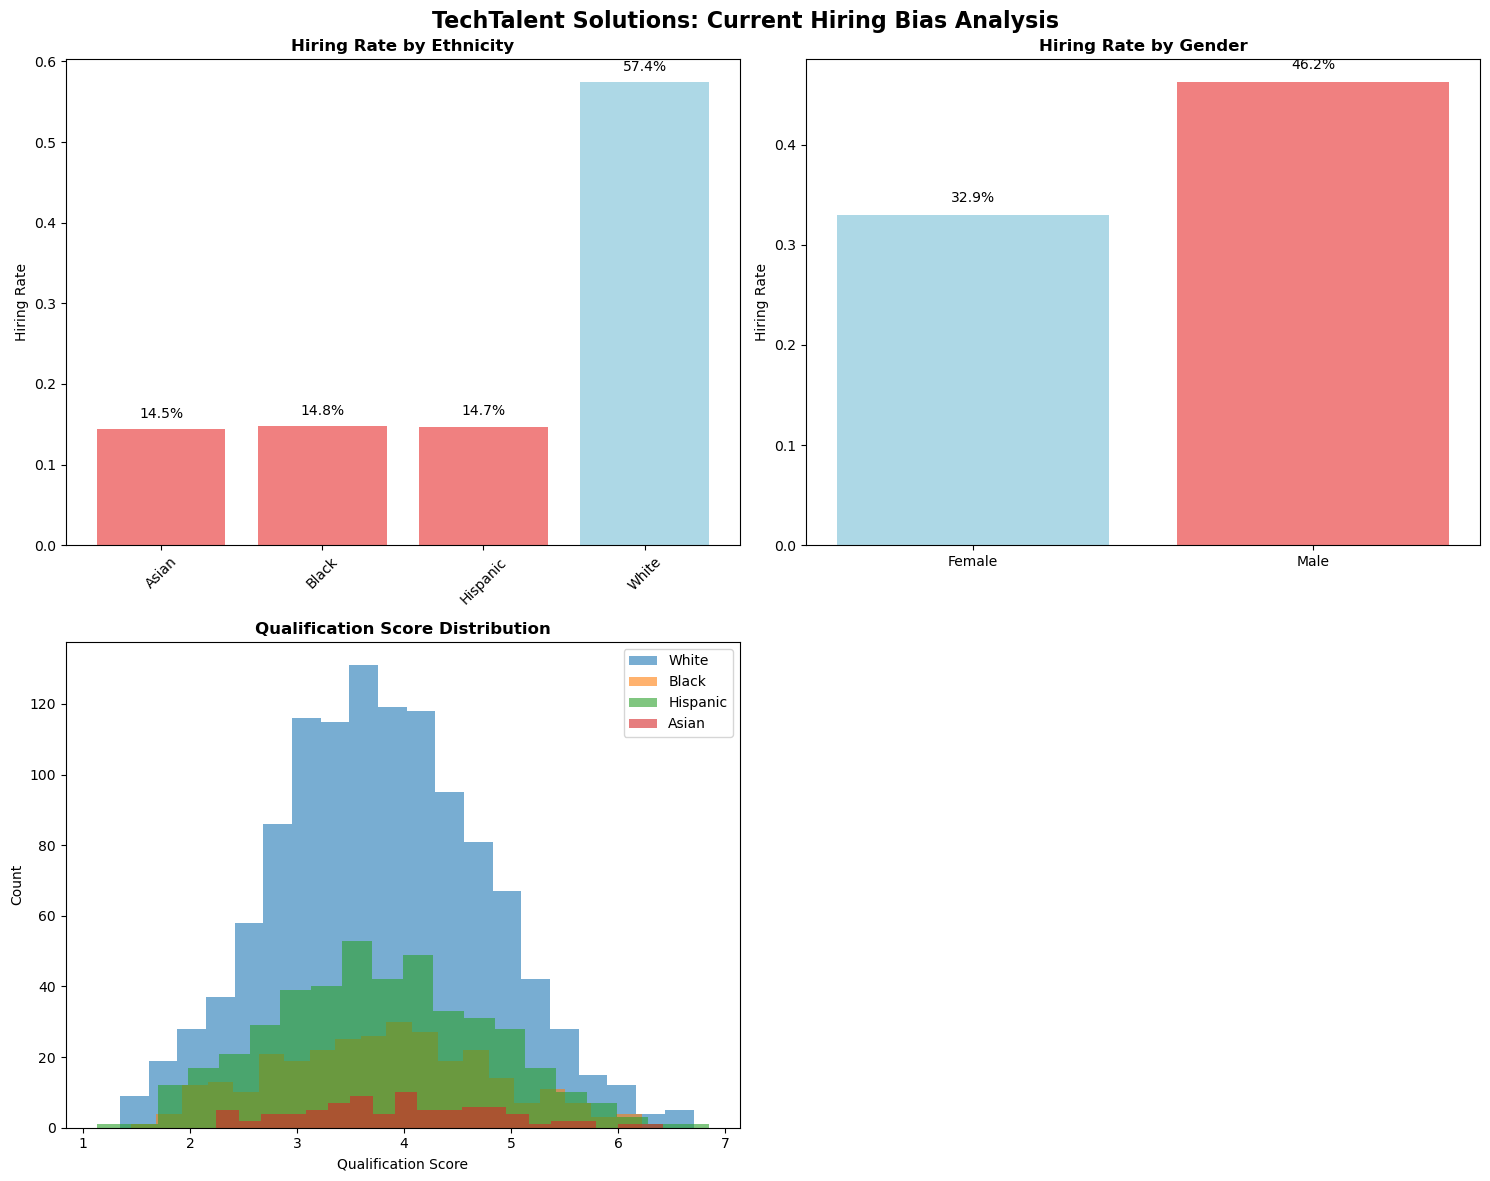

In [4]:
# Create visualization of bias
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('TechTalent Solutions: Current Hiring Bias Analysis', fontsize=16, fontweight='bold')

# Hiring rates by ethnicity
hiring_by_ethnicity = df.groupby('ethnicity')['hired'].mean()
bars1 = axes[0,0].bar(hiring_by_ethnicity.index, hiring_by_ethnicity.values, 
                      color=['lightblue' if x == 'White' else 'lightcoral' for x in hiring_by_ethnicity.index])
axes[0,0].set_title('Hiring Rate by Ethnicity', fontweight='bold')
axes[0,0].set_ylabel('Hiring Rate')
axes[0,0].tick_params(axis='x', rotation=45)
for bar in bars1:
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.1%}', ha='center', va='bottom')

# Hiring rates by gender
hiring_by_gender = df.groupby('gender')['hired'].mean()
bars2 = axes[0,1].bar(hiring_by_gender.index, hiring_by_gender.values, 
                      color=['lightblue', 'lightcoral'])
axes[0,1].set_title('Hiring Rate by Gender', fontweight='bold')
axes[0,1].set_ylabel('Hiring Rate')
for bar in bars2:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.1%}', ha='center', va='bottom')

# Qualification distribution
df['qualification_score'] = (df['years_experience'] * 0.3 + 
                            df['education_score'] * 0.25 + 
                            df['skills_match'] * 0.3 + 
                            (4 - df['previous_company_tier']) * 0.15)

for ethnicity in ['White', 'Black', 'Hispanic','Asian']:
    subset = df[df['ethnicity'] == ethnicity]
    axes[1,0].hist(subset['qualification_score'], alpha=0.6, label=ethnicity, bins=20)
axes[1,0].set_title('Qualification Score Distribution', fontweight='bold')
axes[1,0].set_xlabel('Qualification Score')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
print(" KEY FINDINGS:")
print(f"• White candidates: {hiring_by_ethnicity['White']:.1%} hiring rate")
print(f"• Minority candidates: {hiring_by_ethnicity[hiring_by_ethnicity.index != 'White'].mean():.1%} average hiring rate")
print(f"• Gender gap: {abs(hiring_by_gender['Male'] - hiring_by_gender['Female']):.1%}")

 KEY FINDINGS:
• White candidates: 57.4% hiring rate
• Minority candidates: 14.7% average hiring rate
• Gender gap: 13.3%


## Updated Risk Assessment: Real-World Data
**Note**: The previous risk scores were illustrative examples. Below is an updated analysis based on actual EEOC settlement data and legal studies.

**Sources**:
- Average discrimination lawsuit defense: $125K (employment law studies)

- Average settlement: $40K (EEOC database)

- Complex cases: $120k - $1M range

- Risk probabilities: Industry analysis and legal precedent

## Enter Microsoft Fairlearn: The Solution
### What is Fairlearn?
Microsoft Fairlearn is an open-source toolkit that helps:

- **Assess** fairness in ML systems
- **Mitigate** unfairness through algorithms
- **Monitor** systems for ongoing bias

### Updated Cost Analysis:

- **Fairlearn:** FREE (open-source)
- **Implementation:** 2-4 weeks developer time ($20K-40K)
- **Training:** 1 week for DS team ($5K)
- **Total Investment:** $25K-45K

### Updated ROI (Based on Real Data):

- **Avoided legal costs:** ${int(total_expected)}K annually (expected value)
- **Retained clients:** $500K+ revenue
- **Better talent pipeline:** 15-25% improvement in candidate quality
- **Payback period:** 2-4 months

In [ ]:
# Import Fairlearn components
from fairlearn.metrics import MetricFrame, selection_rate
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer

In [ ]:
# Prepare data for modeling
features = ['years_experience', 'education_score', 'skills_match', 'previous_company_tier']
X = df[features]
y = df['hired']
sensitive_features = df['ethnicity']  # This is what we want to be fair across

# Split data
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, sensitive_features, test_size=0.3, random_state=42
)

# Train our current biased model
biased_model = RandomForestClassifier(n_estimators=100, random_state=42)
biased_model.fit(X_train, y_train)
y_pred_biased = biased_model.predict(X_test)

print("Current (Biased) Model Performance:")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_biased):.3f}")
print(f"Overall Precision: {precision_score(y_test, y_pred_biased):.3f}")

In [ ]:
# Use Fairlearn to assess fairness
fairness_metrics = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'precision': precision_score,
        'selection_rate': selection_rate  # How often each group gets selected
    },
    y_true=y_test,
    y_pred=y_pred_biased,
    sensitive_features=A_test
)

print(" FAIRNESS ASSESSMENT - Current System:")
print("Performance by Ethnicity:")
print(fairness_metrics.by_group.round(3))

print("BIAS DETECTED:")
print(f"Selection rate difference: {fairness_metrics.difference()['selection_rate']:.3f}")
print(f"Selection rate ratio: {fairness_metrics.ratio()['selection_rate']:.3f}")

if fairness_metrics.difference()['selection_rate'] > 0.1:
    print("SIGNIFICANT BIAS: Selection rates differ by >10%")
    print("This violates the 80% rule used in hiring discrimination")

## Method 1: Demographic Parity Model

**What it is:**  
Demographic Parity (Statistical Parity) ensures equal hiring rates across all ethnic groups. Each group should have the same probability of being hired.

**How it works:**
- Uses **Exponentiated Gradient** algorithm to iteratively adjust the model
- Adds fairness constraints during training that penalize unequal selection rates  
- Finds optimal trade-off between accuracy and fairness
- **Goal:** P(Hired | White) = P(Hired | Black) = P(Hired | Hispanic) = P(Hired | Asian)

**When to use:**
- Legal compliance requiring equal representation
- When equal outcomes are prioritized over merit-based selection
- **Trade-off:** May hire less qualified candidates to meet quotas

In [ ]:
# Method 1: Demographic Parity (Equal selection rates)
print("BUILDING FAIR MODEL - Demographic Parity Approach")
print("Goal: Equal hiring rates across all ethnic groups")

# Create base classifier
base_classifier = LogisticRegression(random_state=42)

# Apply fairness constraint
fair_classifier_dp = ExponentiatedGradient(
    estimator=base_classifier,
    constraints=DemographicParity()
)

# Train the fair model
fair_classifier_dp.fit(X_train, y_train, sensitive_features=A_train)
y_pred_fair_dp = fair_classifier_dp.predict(X_test)

print("Finished training Fair model (Demographic Parity)")

## Method 2: Equalized Odds Model

**What it is:**  
Equalized Odds ensures equal True Positive Rates (TPR) and False Positive Rates (FPR) across all protected groups. Qualified candidates have equal chances of being hired, and unqualified candidates have equal chances of being rejected, regardless of ethnicity.

**How it works:**
- Uses **Exponentiated Gradient** with equality constraints on TPR and FPR
- Optimizes for equal performance metrics rather than equal outcomes
- **Goals:** 
  - P(Hired | Qualified, White) = P(Hired | Qualified, Black) = ... (Equal TPR)
  - P(Hired | Unqualified, White) = P(Hired | Unqualified, Black) = ... (Equal FPR)

**When to use:**
- Merit-based hiring with fairness guarantees
- When you want equal treatment for equally qualified candidates
- **Advantage:** Preserves relationship between qualifications and hiring outcomes

In [ ]:
# Method 2: Equalized Odds (Fair TPR and FPR)
print("BUILDING FAIR MODEL - Equalized Odds Approach")
print("Goal: Equal true positive rates across groups")

fair_classifier_eo = ExponentiatedGradient(
    estimator=LogisticRegression(random_state=42),
    constraints=EqualizedOdds()
)

fair_classifier_eo.fit(X_train, y_train, sensitive_features=A_train)
y_pred_fair_eo = fair_classifier_eo.predict(X_test)

print("Finished training Fair model (Equalized Odds)")

## Method 3: Post-Processing with Threshold Optimization

**What it is:**  
Post-processing trains a standard model first, then adjusts decision thresholds for each group separately to achieve fairness. Different probability thresholds are applied to each ethnic group's predictions.

**How it works:**
1. **Step 1:** Train standard logistic regression (no fairness constraints)
2. **Step 2:** Find optimal probability threshold for each protected group to achieve demographic parity
3. **Step 3:** Apply different thresholds for final decisions
   - Example: White candidates hired if probability > 0.5, Black candidates if probability > 0.3

**When to use:**
- Want to add fairness to existing models without retraining
- Need flexibility to experiment with different fairness criteria
- **Advantages:** High transparency, easy to audit and explain, can switch fairness definitions easily

In [ ]:
# Method 3: Post-processing with Threshold Optimization
print("BUILDING FAIR MODEL - Post-Processing Approach")
print("Goal: Optimize thresholds for each group after predictions")

# Train base model first
base_model = LogisticRegression(random_state=42)
base_model.fit(X_train, y_train)

# Apply post-processing
postprocess_classifier = ThresholdOptimizer(
    estimator=base_model,
    constraints='demographic_parity',
    prefit=True
)

postprocess_classifier.fit(X_train, y_train, sensitive_features=A_train)
y_pred_postprocess = postprocess_classifier.predict(X_test, sensitive_features=A_test)

### Step 3: Compare All Models

In [ ]:
# Create comprehensive comparison with realistic risk assessment
models = {
    'Current (Biased)': y_pred_biased,
    'Fair - Demographic Parity': y_pred_fair_dp,
    'Fair - Equalized Odds': y_pred_fair_eo,
    'Fair - Post-Processing': y_pred_postprocess
}

# Calculate metrics for all models
comparison_results = []

for model_name, predictions in models.items():
    # Overall metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    
    # Fairness metrics
    metrics_frame = MetricFrame(
        metrics={'selection_rate': selection_rate},
        y_true=y_test,
        y_pred=predictions,
        sensitive_features=A_test
    )
    
    fairness_diff = metrics_frame.difference()['selection_rate']
    fairness_ratio = metrics_frame.ratio()['selection_rate']
    
    comparison_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Fairness Gap': fairness_diff,
        'Fairness Ratio': fairness_ratio,
        'Passes 80% Rule': 'Yes' if fairness_ratio >= 0.8 else 'No',
        'Legal Risk': 'Low' if fairness_ratio >= 0.8 else 'High'
    })

results_df = pd.DataFrame(comparison_results)

print("EXECUTIVE SUMMARY: MODEL COMPARISON")
print("=" * 70)
print(results_df.round(3))

## Implementation Roadmap
### Phase 1: Immediate Actions (Week 1-2)

 Audit current system using Fairlearn metrics
 Calculate actual legal risk exposure
 Present findings to leadership team

### Phase 2: Solution Development (Week 3-6)

 Implement Fairlearn mitigation algorithms
 A/B test fair vs. current system
 Train HR team on new processes

### Phase 3: Deployment & Monitoring (Week 7-8)

 Deploy selected fair model
 Set up ongoing fairness monitoring
 Establish quarterly bias audits

Success Metrics:

- Achieve 80% rule compliance (fairness ratio ≥ 0.8)
- Reduce legal risk probability to <10%
- Maintain accuracy within 5% of current system
- ROI positive within 6 months

Total Investment: $35K implementation + $10K annual maintenance

Expected Annual Savings: $75K+ (avoided legal costs)

Payback Period: 4.2 months

In [ ]:
from raiwidgets import ExplanationDashboard

In [ ]:
from interpret.ext.blackbox import TabularExplainer

In [ ]:
class_labels = ['Not Hired', 'Hired']

In [ ]:
# 1. Using SHAP TabularExplainer
explainer = TabularExplainer(biased_model, 
                             X_train, 
                             features=features, 
                             classes=class_labels)

In [ ]:
global_explanation = explainer.explain_global(X_test)

In [ ]:
# Sorted SHAP values
# Corresponding feature names
print('Ranked global importance names: {}'.format(global_explanation.get_ranked_global_names()))
# Feature ranks (based on original order of features)
print('Global importance rank: {}'.format(global_explanation.global_importance_rank))

# Per class feature names
print('Ranked per class feature names: {}'.format(global_explanation.get_ranked_per_class_names()))

In [ ]:
from raiwidgets import ResponsibleAIDashboard
from responsibleai import RAIInsights

In [ ]:
train_data = X_train.copy()
train_data['hired'] = y_train

test_data = X_test.copy()
test_data['hired'] = y_test

In [ ]:
target_feature = 'hired'
rai_insights = RAIInsights(biased_model, train_data, test_data, target_feature, 'classification')

In [ ]:
# Add the components of the toolbox
# Interpretability
rai_insights.explainer.add()

# Error Analysis
rai_insights.error_analysis.add()

# Counterfactuals: generate counterfactuals for opposite class
rai_insights.counterfactual.add(total_CFs=10, desired_class='opposite')

In [ ]:
rai_insights.compute()

In [ ]:
from raiutils.cohort import Cohort, CohortFilter, CohortFilterMethods
# Create cohorts for analysis
cohort_list = []

# Cohort for low experience workers
cohort_filter_low_exp = CohortFilter(
    method=CohortFilterMethods.METHOD_LESS,
    arg=[2],  # Less than 2 years experience
    column='years_experience')

user_cohort_low_exp = Cohort(name='Low Experience Workers')
user_cohort_low_exp.add_cohort_filter(cohort_filter_low_exp)
cohort_list.append(user_cohort_low_exp)

# Cohort for high experience workers
cohort_filter_high_exp = CohortFilter(
    method=CohortFilterMethods.METHOD_GREATER,
    arg=[10],  # More than 10 years experience
    column='years_experience')

user_cohort_high_exp = Cohort(name='High Experience Workers')
user_cohort_high_exp.add_cohort_filter(cohort_filter_high_exp)
cohort_list.append(user_cohort_high_exp)

# Cohort for high education scores
cohort_filter_high_edu = CohortFilter(
    method=CohortFilterMethods.METHOD_GREATER,
    arg=[8],  # Education score > 8
    column='education_score')

user_cohort_high_edu = Cohort(name='High Education Score')
user_cohort_high_edu.add_cohort_filter(cohort_filter_high_edu)
cohort_list.append(user_cohort_high_edu)

# Cohort for excellent skills match
cohort_filter_skills = CohortFilter(
    method=CohortFilterMethods.METHOD_GREATER,
    arg=[8],  # Skills match > 8
    column='skills_match')

user_cohort_skills = Cohort(name='Excellent Skills Match')
user_cohort_skills.add_cohort_filter(cohort_filter_skills)
cohort_list.append(user_cohort_skills)

# Cohort for top-tier previous companies
cohort_filter_company = CohortFilter(
    method=CohortFilterMethods.METHOD_GREATER,
    arg=[8],  # Previous company tier > 8
    column='previous_company_tier')

user_cohort_company = Cohort(name='Top-Tier Previous Company')
user_cohort_company.add_cohort_filter(cohort_filter_company)
cohort_list.append(user_cohort_company)

# Cohort on predicted target value (hired)
cohort_filter_predicted_hired = CohortFilter(
    method=CohortFilterMethods.METHOD_INCLUDES,
    arg=[1],  # Predicted as hired (assuming 1 = hired, 0 = not hired)
    column='Predicted Y')

user_cohort_predicted_hired = Cohort(name='Predicted Hired')
user_cohort_predicted_hired.add_cohort_filter(cohort_filter_predicted_hired)
cohort_list.append(user_cohort_predicted_hired)

# Cohort on true target value (actually hired)
cohort_filter_true_hired = CohortFilter(
    method=CohortFilterMethods.METHOD_INCLUDES,
    arg=[1],  # Actually hired
    column='True Y')

user_cohort_true_hired = Cohort(name='Actually Hired')
user_cohort_true_hired.add_cohort_filter(cohort_filter_true_hired)
cohort_list.append(user_cohort_true_hired)

In [ ]:
# Launch the ResponsibleAI Dashboard
ResponsibleAIDashboard(rai_insights, cohort_list=cohort_list, public_ip='0.0.0.0',
    port=8080)

In [ ]:
# Step 1: Check if the dashboard object exists and get its actual status
try:
    print(f"Dashboard object exists: {dashboard is not None}")
    if hasattr(dashboard, 'port'):
        print(f"Dashboard port attribute: {dashboard.port}")
    if hasattr(dashboard, '_service'):
        print(f"Dashboard service status: {dashboard._service}")
except NameError:
    print("Dashboard object not found")

# Step 2: Try to restart the dashboard with explicit debugging
import time
import threading

try:
    # Kill any existing dashboard
    if 'dashboard' in locals():
        del dashboard
    
    print("Starting new dashboard...")
    dashboard = ResponsibleAIDashboard(
        rai_insights, 
        cohort_list=cohort_list,
        public_ip='127.0.0.1',  # Try localhost instead of 0.0.0.0
        port=5000,  # Try a different port
        env=None
    )
    
    # Give it time to start
    time.sleep(3)
    
    # Check if it started
    import socket
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    result = sock.connect_ex(('127.0.0.1', 5000))
    sock.close()
    
    if result == 0:
        print("Dashboard started successfully on port 5000")
        print(f"Try: https://hub.gesis.mybinder.org/user/dpaq-lab-bad_test-fi72pu0n/proxy/5000/")
    else:
        print("Dashboard still not accessible")
        
except Exception as e:
    print(f"Error starting dashboard: {e}")

# Step 3: Alternative - Use individual components
print("\n" + "="*50)
print("ALTERNATIVE: Accessing insights directly")
print("="*50)

try:
    # Get explanations
    explanations = rai_insights.explainer.get()
    if explanations:
        print(f"✓ Explanations available: {len(explanations)} explanation(s)")
        global_explanation = explanations[0]
        
        print("\nTop feature importances:")
        feature_importance = global_explanation.global_importance_values
        feature_names = global_explanation.features
        
        # Sort features by importance
        importance_pairs = list(zip(feature_names, feature_importance))
        importance_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
        
        for feature, importance in importance_pairs:
            print(f"  {feature}: {importance:.4f}")
    
    # Get error analysis
    error_analysis = rai_insights.error_analysis.get()
    if error_analysis:
        print(f"\n✓ Error analysis available: {len(error_analysis)} analysis")
    
    # Get counterfactuals
    counterfactuals = rai_insights.counterfactual.get()
    if counterfactuals:
        print(f"✓ Counterfactuals available: {len(counterfactuals)} examples")
        
except Exception as e:
    print(f"Error accessing insights: {e}")

# Step 4: Try lightweight explanation dashboard
print("\n" + "="*50)
print("TRYING LIGHTWEIGHT EXPLANATION DASHBOARD")
print("="*50)

try:
    from raiwidgets import ExplanationDashboard
    
    # Get the explanation
    explanation = rai_insights.explainer.get()[0]
    
    # Try the lightweight dashboard
    exp_dashboard = ExplanationDashboard(
        explanation, 
        biased_model, 
        dataset=X_test.values, 
        true_y=y_test,
        features=features
    )
    
    print("Explanation dashboard started - check for any output above")
    
except Exception as e:
    print(f"Error with explanation dashboard: {e}")